In [1]:
# Imports Libraries
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, correlate
from scipy.stats import pearsonr, linregress

In [2]:
# Read everything in the data file into lines
# lines is a list, each element is one line in the data file
file_path = "3.13.26 Kristen Pulley"
file = open("data/" + file_path + ".txt", "r")
lines = file.readlines()


# Finds where the raw data starts
# Skips the two blank lines at very beginning
i = 0
while lines[i] != "4) Trace Data\n":
    i += 1
i += 2


# Read All Raw LDF Data
raw_data_ldf = []
for j in range(i, len(lines)):
    line = lines[j]
    ldf_val = float(line.split("\t")[4])
    raw_data_ldf.append(ldf_val)

# See if the last datapoint is correct
print(raw_data_ldf[-1])

355.4


In [3]:
# Read everything in the data file into lines
file_path = "3.13.26 Kristen Pulley(real)"
file = open("data/" + file_path + ".csv", "r")
lines = file.readlines()

# Finds where the raw data starts
# Skips the one blank line at very beginning
i = 0
while lines[i] != "No,Time (hr:min:sec),LeftLU,Event messages\n":
    i += 1
i += 1

# Read how many lines we need to read in AMI
numDataLines = int(lines[13].split(",")[1])

raw_data_ami = []
for j in range(i, i + numDataLines):
    line = lines[j]
    ami_val = float(line.split(",")[2])
    raw_data_ami.append(ami_val)

# See if the last datapoint is correct
print(raw_data_ami[-1])

3127.0


In [4]:

# ALIGN SIGNALS
# Both LDF and AMI are sampled at 1 Hz (1 value per second).
# If they have different lengths, we trim to the shorter one.
ldf = np.array(raw_data_ldf)
ami = np.array(raw_data_ami)

n = min(len(ldf), len(ami))
ldf_aligned = ldf[:n]
ami_aligned = ami[:n]
time_s = np.arange(n)  # time axis in seconds

print(f"LDF length:     {len(ldf)} samples")
print(f"AMI length:     {len(ami)} samples")
print(f"Aligned length: {n} samples ({n / 60:.1f} minutes)")

LDF length:     1601 samples
AMI length:     1596 samples
Aligned length: 1596 samples (26.6 minutes)


Pearson r = -0.2248
p-value   = 9.9997e-20
=> Statistically significant negative correlation (p < 0.05)


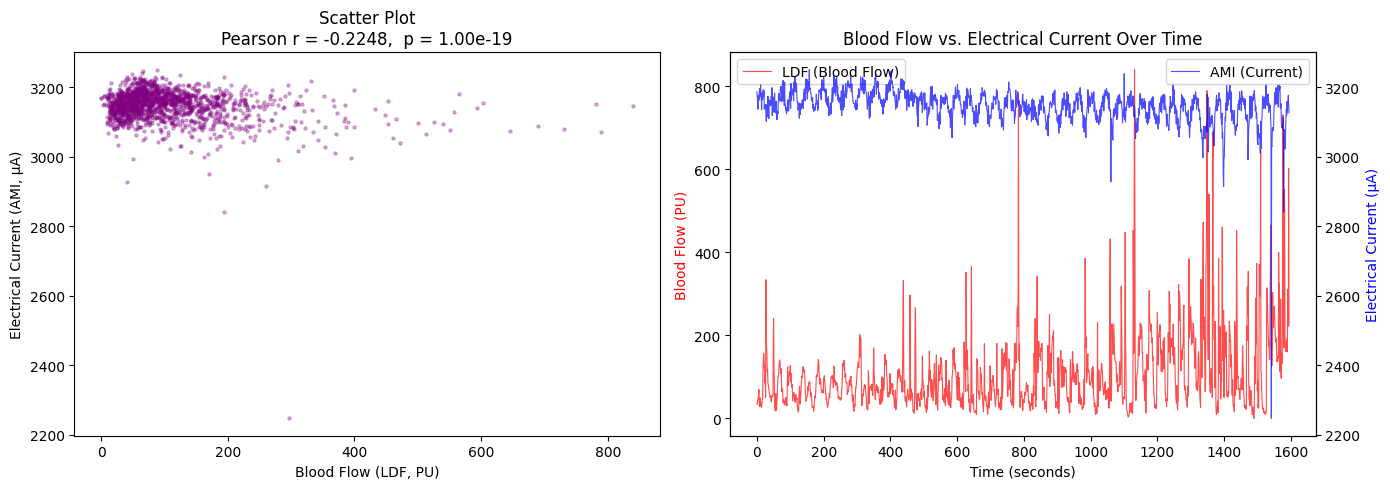

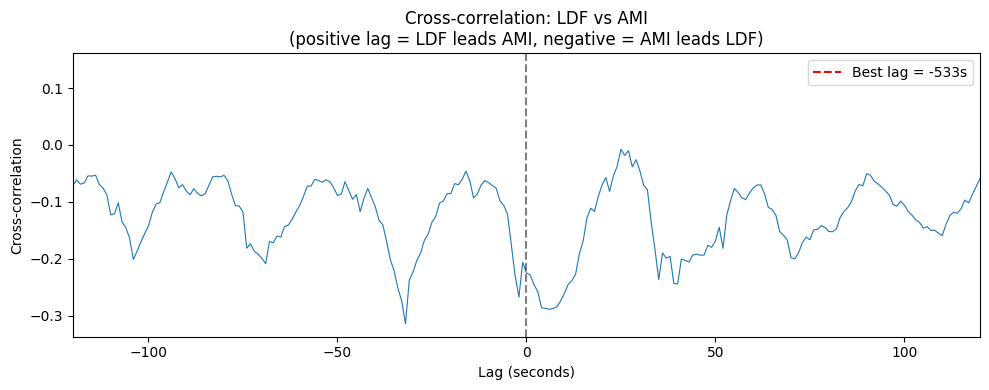

Peak cross-correlation at lag = -533 seconds
  => Electrical current (AMI) leads blood flow (LDF) by 533s


In [ ]:
# ANALYSIS 1: CORRELATION BETWEEN BLOOD FLOW AND CURRENT
# Pearson correlation (overall linear relationship)

r, p = pearsonr(ldf_aligned, ami_aligned)
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.4e}")
if p < 0.05:
    direction = "positive" if r > 0 else "negative"
    print(f"=> Statistically significant {direction} correlation (p < 0.05)")
else:
    print("=> No statistically significant correlation (p >= 0.05)")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ldf_aligned, ami_aligned, alpha=0.3, s=5, color='purple')
axes[0].set_xlabel("Blood Flow (LDF, PU)")
axes[0].set_ylabel("Electrical Current (AMI, µA)")
axes[0].set_title(f"Scatter Plot\nPearson r = {r:.4f},  p = {p:.2e}")

# --- Dua
ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(time_s, ldf_aligned, color='red',  alpha=0.7, linewidth=0.8, label='LDF (Blood Flow)')
ax2.plot(time_s, ami_aligned, color='blue', alpha=0.7, linewidth=0.8, label='AMI (Current)')
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Blood Flow (PU)", color='red')
ax2.set_ylabel("Electrical Current (µA)", color='blue')
ax1.set_title("Blood Flow vs. Electrical Current Over Time")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# --- Cross-correlation (which signal leads the other?) ---
ldf_norm = (ldf_aligned - ldf_aligned.mean()) / ldf_aligned.std()
ami_norm = (ami_aligned - ami_aligned.mean()) / ami_aligned.std()
xcorr = correlate(ldf_norm, ami_norm, mode='full') / n
lags = np.arange(-(n - 1), n)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags, xcorr, linewidth=0.8)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
best_lag = lags[np.argmax(xcorr)]
ax.axvline(best_lag, color='r', linestyle='--', label=f'Best lag = {best_lag}s')
ax.set_xlabel("Lag (seconds)")
ax.set_ylabel("Cross-correlation")
ax.set_title("Cross-correlation: LDF vs AMI\n(positive lag = LDF leads AMI, negative = AMI leads LDF)")
ax.set_xlim(-120, 120)  # show ± 2 minutes
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak cross-correlation at lag = {best_lag} seconds")
if best_lag > 0:
    print(f"  => Blood flow (LDF) leads electrical current (AMI) by {best_lag}s")
elif best_lag < 0:
    print(f"  => Electrical current (AMI) leads blood flow (LDF) by {-best_lag}s")
else:
    print("  => Signals are synchronous (no lag)")

Detected 156 peaks in LDF (blood flow)
Detected 72 peaks in AMI (electrical current)


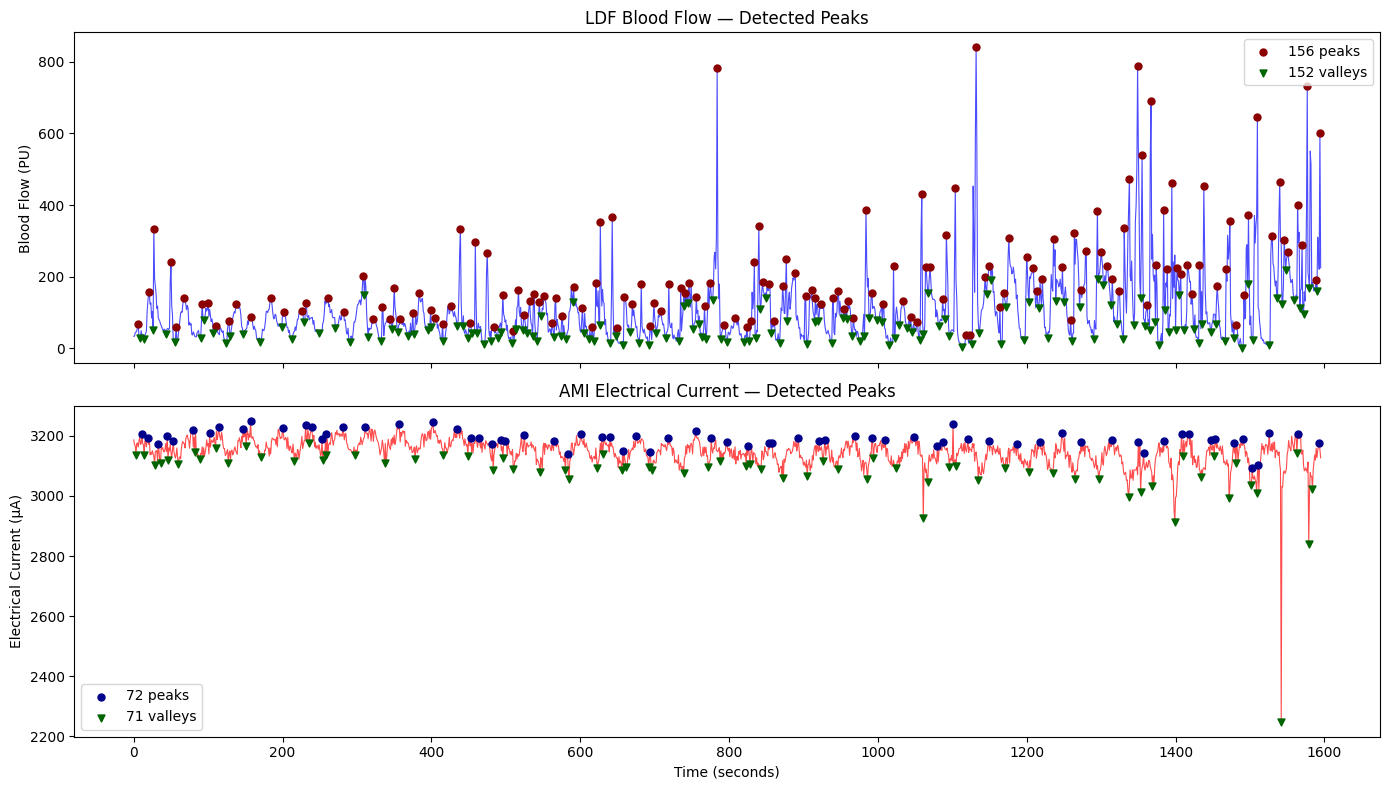

In [14]:
# ANALYSIS 2: DETECT LOCAL PEAKS IN BOTH SIGNALS
# Tune `distance` and `prominence` to match the scale of data.  

# --- LDF peaks ---
ldf_peaks_idx, _ = find_peaks(
    ldf_aligned,
    distance=5,      # at least 5 s between peaks
    prominence=20    # must stand out by ≥ 20 PU
)
ldf_peak_times   = time_s[ldf_peaks_idx]
ldf_peak_heights = ldf_aligned[ldf_peaks_idx]


# --- LDF valleys (using same logic on inverted signal) ---
ldf_valleys_idx, _ = find_peaks(
    -ldf_aligned,
    distance=5,      # at least 5 s between valleys
    prominence=20    # must drop by ≥ 20 PU
)
ldf_valley_times   = time_s[ldf_valleys_idx]
ldf_valley_heights = ldf_aligned[ldf_valleys_idx]  # original heights, not inverted

# --- AMI peaks ---
ami_peaks_idx, _ = find_peaks(
    ami_aligned,
    distance=5,      # at least 5 s between peaks
    prominence=50    # adjust based on AMI signal scale (µA)
)
ami_peak_times   = time_s[ami_peaks_idx]
ami_peak_heights = ami_aligned[ami_peaks_idx]


ami_valleys_idx, _ = find_peaks(
    -ami_aligned,
    distance=5,      # at least 5 s between valleys
    prominence=50    # must drop by ≥ 20 PU
)
ami_valley_times   = time_s[ami_valleys_idx]
ami_valley_heights = ami_aligned[ami_valleys_idx]  # original heights, not inverted


print(f"Detected {len(ldf_peaks_idx)} peaks in LDF (blood flow)")
print(f"Detected {len(ami_peaks_idx)} peaks in AMI (electrical current)")

# --- Plot signals with peaks marked ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(time_s, ldf_aligned, color='blue', alpha=0.7, linewidth=0.8)
ax1.scatter(ldf_peak_times, ldf_peak_heights,
            color='darkred', s=25, zorder=5, label=f'{len(ldf_peaks_idx)} peaks')
ax1.scatter(ldf_valley_times, ldf_valley_heights,
            color='darkgreen', s=25, zorder=5, marker='v', label=f'{len(ldf_valleys_idx)} valleys')
ax1.set_ylabel("Blood Flow (PU)")
ax1.set_title("LDF Blood Flow — Detected Peaks")
ax1.legend()



ax2.plot(time_s, ami_aligned, color='red', alpha=0.7, linewidth=0.8)
ax2.scatter(ami_peak_times, ami_peak_heights,
            color='darkblue', s=25, zorder=5, label=f'{len(ami_peaks_idx)} peaks')
ax2.scatter(ami_valley_times, ami_valley_heights,
            color='darkgreen', s=25, zorder=5, marker='v', label=f'{len(ami_valleys_idx)} valleys')
ax2.set_ylabel("Electrical Current (µA)")
ax2.set_xlabel("Time (seconds)")
ax2.set_title("AMI Electrical Current — Detected Peaks")
ax2.legend()

plt.tight_layout()
plt.show()


  LDF (Blood Flow) — Peak Height Trend
  Slope:    +0.1643 units/second  (+9.856 units/min)
  R²:       0.2230
  p-value:  4.8626e-10
  => Statistically significant INCREASING trend (p < 0.05)

  Consecutive peak-height changes:
  Mean Δ = +3.44,  Std Δ = 192.14
  => STEP-LIKE pattern — 11 sudden jump(s) detected:
     t=775s → t=784s : 181.4 → 781.8 (Δ=+600.4,  z=+3.1)
     t=784s → t=793s : 781.8 → 64.4 (Δ=-717.4,  z=-3.8)
     t=1104s → t=1119s : 448.1 → 36.3 (Δ=-411.8,  z=-2.2)
     t=1124s → t=1132s : 37.7 → 840.0 (Δ=+802.3,  z=+4.2)
     t=1132s → t=1144s : 840.0 → 198.4 (Δ=-641.6,  z=-3.4)
     t=1355s → t=1362s : 539.5 → 120.6 (Δ=-418.9,  z=-2.2)
     t=1362s → t=1367s : 120.6 → 690.2 (Δ=+569.6,  z=+2.9)
     t=1367s → t=1374s : 690.2 → 233.1 (Δ=-457.1,  z=-2.4)
     t=1570s → t=1577s : 287.2 → 731.2 (Δ=+444.0,  z=+2.3)
     t=1577s → t=1589s : 731.2 → 190.5 (Δ=-540.7,  z=-2.8)
     t=1589s → t=1594s : 190.5 → 602.4 (Δ=+411.9,  z=+2.1)


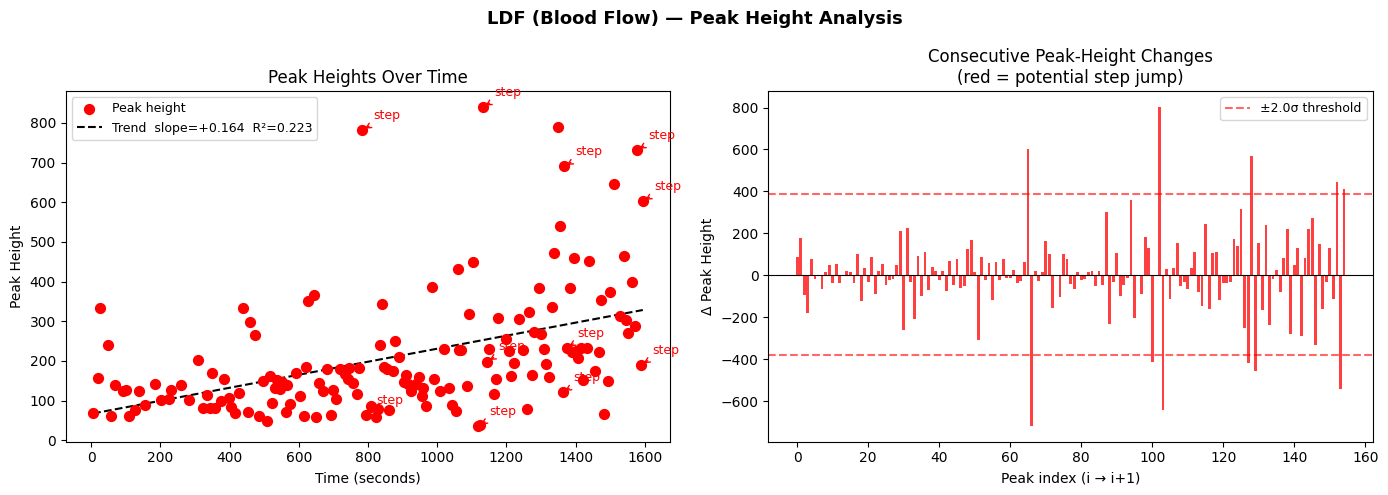


  AMI (Electrical Current) — Peak Height Trend
  Slope:    -0.0261 units/second  (-1.564 units/min)
  R²:       0.1944
  p-value:  1.1875e-04
  => Statistically significant DECREASING trend (p < 0.05)

  Consecutive peak-height changes:
  Mean Δ = -0.43,  Std Δ = 30.52
  => STEP-LIKE pattern — 3 sudden jump(s) detected:
     t=583s → t=601s : 3139.0 → 3208.0 (Δ=+69.0,  z=+2.3)
     t=1491s → t=1503s : 3191.0 → 3092.0 (Δ=-99.0,  z=-3.2)
     t=1511s → t=1526s : 3102.0 → 3211.0 (Δ=+109.0,  z=+3.6)


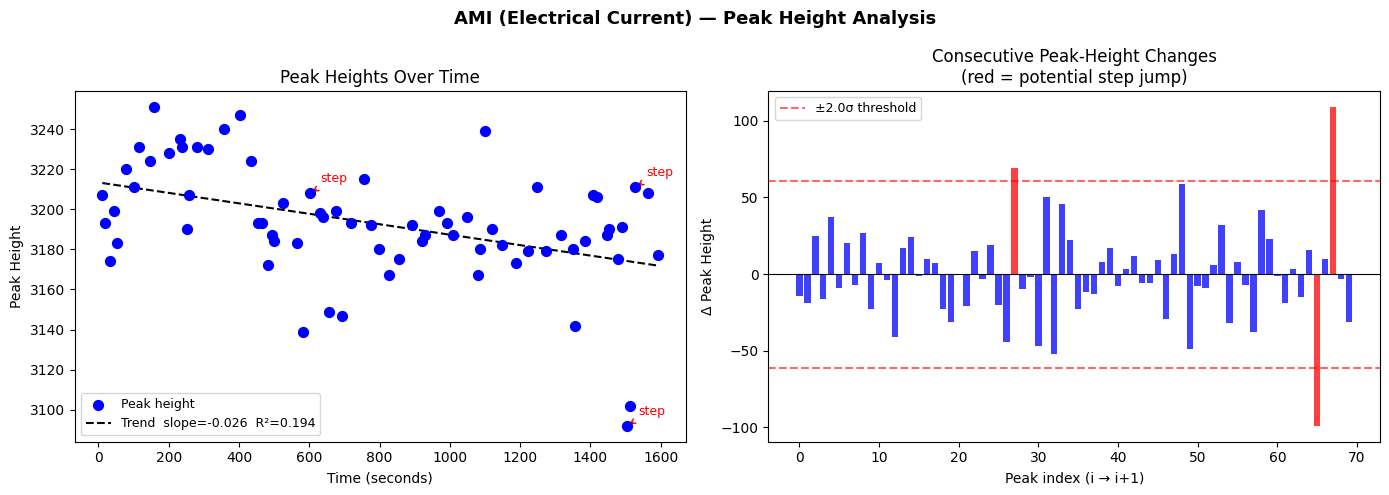

In [ ]:
# ANALYSIS 3: DO PEAK HEIGHTS INCREASE OVER TIME?
#             AND IS THE INCREASE SMOOTH OR STEP-LIKE?
#
# Method:
#   - Linear regression on peak heights vs. time → trend direction
#   - First-differences of consecutive peak heights → change pattern
#   - A z-score > 2 on any single jump flags it as a "step"

def analyze_peak_trend(peak_times, peak_heights, signal_name, color):

    if len(peak_times) < 3:
        print(f"{signal_name}: Not enough peaks to analyze trend (need >= 3).")
        return

    
    # Linear regression
    slope, intercept, r_val, p_val, _ = linregress(peak_times, peak_heights)

    print(f"\n{'=' * 55}")
    print(f"  {signal_name} — Peak Height Trend")
    print(f"{'=' * 55}")
    print(f"  Slope:    {slope:+.4f} units/second  ({slope * 60:+.3f} units/min)")
    print(f"  R²:       {r_val**2:.4f}")
    print(f"  p-value:  {p_val:.4e}")
    if p_val < 0.05:
        direction = "INCREASING" if slope > 0 else "DECREASING"
        print(f"  => Statistically significant {direction} trend (p < 0.05)")
    else:
        print(f"  => No significant trend detected (p >= 0.05)")
    axL.scatter(peak_times, peak_heights, color=color, s=50, zorder=5, label='Peak height')
    trend = slope * peak_times + intercept
    axL.plot(peak_times, trend, 'k--', linewidth=1.5,
             label=f'Trend  slope={slope:+.3f}  R²={r_val**2:.3f}')
    # Mark step transitions on the scatter plot
    for si in step_indices:
        axL.annotate('step', xy=(peak_times[si + 1], peak_heights[si + 1]),
                     xytext=(8, 8), textcoords='offset points',
                     color='red', fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='red'))
    axL.set_xlabel("Time (seconds)")
    axL.set_ylabel("Peak Height")
    axL.set_title("Peak Heights Over Time")
    axL.legend(fontsize=9)

    # Smooth vs. step-like
    diffs = np.diff(peak_heights)          # change from one peak to the next
    mean_d = np.mean(diffs)
    std_d  = np.std(diffs)

    if std_d > 0:
        z_scores = (diffs - mean_d) / std_d
    else:
        z_scores = np.zeros_like(diffs)

    # A "step" is a single jump whose z-score exceeds the threshold
    STEP_THRESHOLD = 2.0
    step_indices = np.where(np.abs(z_scores) > STEP_THRESHOLD)[0]

    print(f"\n  Consecutive peak-height changes:")
    print(f"  Mean Δ = {mean_d:+.2f},  Std Δ = {std_d:.2f}")
    if len(step_indices) > 0:
        print(f"  => STEP-LIKE pattern — {len(step_indices)} sudden jump(s) detected:")
        for si in step_indices:
            print(f"     t={peak_times[si]:.0f}s → t={peak_times[si+1]:.0f}s : "
                  f"{peak_heights[si]:.1f} → {peak_heights[si+1]:.1f} "
                  f"(Δ={diffs[si]:+.1f},  z={z_scores[si]:+.1f})")
    else:
        print(f"  => SMOOTH pattern — no sudden jumps detected")

    
    # Plots
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{signal_name} — Peak Height Analysis", fontsize=13, fontweight='bold')

    # Left: peak heights over time + trend line
    axL.scatter(peak_times, peak_heights, color=color, s=50, zorder=5, label='Peak height')
    trend = slope * peak_times + intercept
    axL.plot(peak_times, trend, 'k--', linewidth=1.5,
             label=f'Trend  slope={slope:+.3f}  R²={r_val**2:.3f}')
    # Mark step transitions on the scatter plot
    for si in step_indices:
        axL.annotate('step', xy=(peak_times[si + 1], peak_heights[si + 1]),
                     xytext=(8, 8), textcoords='offset points',
                     color='red', fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='red'))
    axL.set_xlabel("Time (seconds)")
    axL.set_ylabel("Peak Height")
    axL.set_title("Peak Heights Over Time")
    axL.legend(fontsize=9)

    # Right: bar chart of consecutive differences
    bar_colors = ['red' if abs(z) > STEP_THRESHOLD else color for z in z_scores]
    axR.bar(range(len(diffs)), diffs, color=bar_colors, alpha=0.75)
    axR.axhline(0, color='k', linewidth=0.8)
    axR.axhline(mean_d + STEP_THRESHOLD * std_d, color='red', linestyle='--',
                alpha=0.6, label=f'±{STEP_THRESHOLD}σ threshold')
    axR.axhline(mean_d - STEP_THRESHOLD * std_d, color='red', linestyle='--', alpha=0.6)
    axR.set_xlabel("Peak index (i → i+1)")
    axR.set_ylabel("Δ Peak Height")
    axR.set_title("Consecutive Peak-Height Changes\n(red = potential step jump)")
    axR.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# Run the analysis for both signals
analyze_peak_trend(ldf_peak_times, ldf_peak_heights, "LDF (Blood Flow)",           "red")
analyze_peak_trend(ami_peak_times, ami_peak_heights, "AMI (Electrical Current)",   "blue")


  LDF (Blood Flow) — Peak Height Trend (Relative to Most Recent Valley)
  Slope:    +0.1231 units/second  (+7.387 units/min)
  R²:       0.1255
  p-value:  6.1323e-06
  => Statistically significant INCREASING trend (p < 0.05)

  AMI (Electric Flow) — Peak Height Trend (Relative to Most Recent Valley)
  Slope:    +0.0364 units/second  (+2.182 units/min)
  R²:       0.1720
  p-value:  2.9264e-04
  => Statistically significant INCREASING trend (p < 0.05)


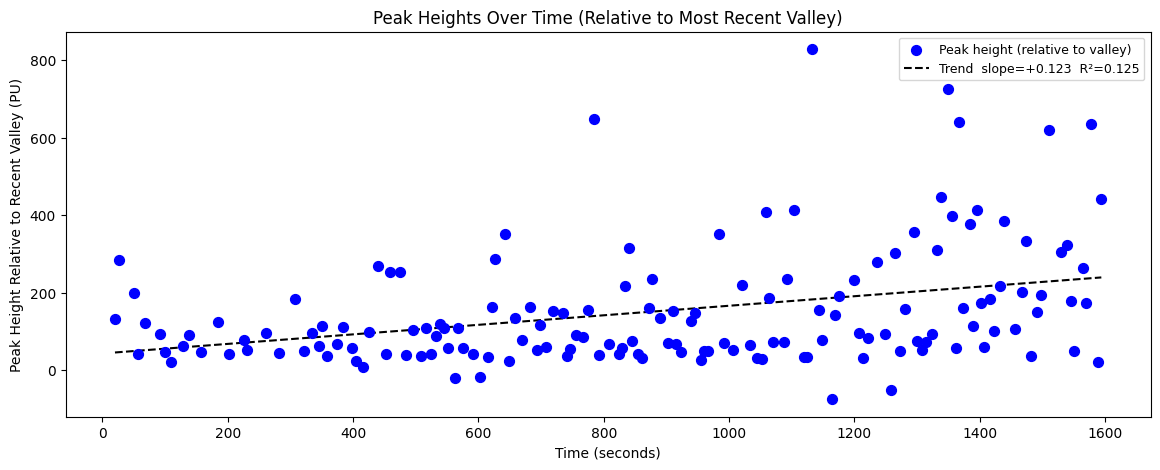

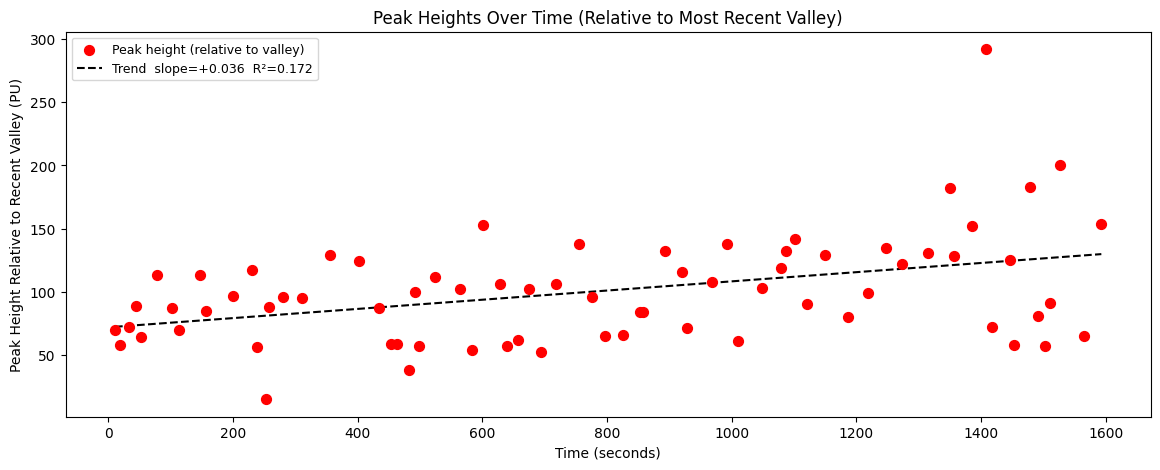

In [13]:
def analyze_peak_trend(peak_times, peak_heights, valley_times, valley_heights, signal_name, color):
    
    if len(peak_times) < 3:
        print(f"{signal_name}: Not enough peaks to analyze trend (need >= 3).")
        return
    
    # Calculate relative peak heights (peak height minus most recent valley height)
    relative_heights = []
    valid_peak_indices = []
    
    for i, peak_time in enumerate(peak_times):
        # Find most recent valley before this peak
        recent_valleys = valley_times[valley_times < peak_time]
        if len(recent_valleys) > 0:
            most_recent_valley_time = recent_valleys[-1]
            most_recent_valley_idx = np.where(valley_times == most_recent_valley_time)[0][0]
            most_recent_valley_height = valley_heights[most_recent_valley_idx]
            
            relative_height = peak_heights[i] - most_recent_valley_height
            relative_heights.append(relative_height)
            valid_peak_indices.append(i)
    
    if len(relative_heights) < 3:
        print(f"{signal_name}: Not enough valid peak-valley pairs to analyze trend (need >= 3).")
        return
    
    # Use only peaks with valid valley references
    valid_peak_times = peak_times[valid_peak_indices]
    valid_peak_heights = np.array(relative_heights)
    
    # Linear regression on relative heights
    slope, intercept, r_val, p_val, _ = linregress(valid_peak_times, valid_peak_heights)
    
    print(f"\n{'=' * 55}")
    print(f"  {signal_name} — Peak Height Trend (Relative to Most Recent Valley)")
    print(f"{'=' * 55}")
    print(f"  Slope:    {slope:+.4f} units/second  ({slope * 60:+.3f} units/min)")
    print(f"  R²:       {r_val**2:.4f}")
    print(f"  p-value:  {p_val:.4e}")
    if p_val < 0.05:
        direction = "INCREASING" if slope > 0 else "DECREASING"
        print(f"  => Statistically significant {direction} trend (p < 0.05)")
    else:
        print(f"  => No significant trend detected (p >= 0.05)")
    fig, (axL) = plt.subplots(1, 1, figsize=(14, 5))
    # Plot relative heights
    axL.scatter(valid_peak_times, valid_peak_heights, color=color, s=50, zorder=5, 
                label='Peak height (relative to valley)')
    trend = slope * valid_peak_times + intercept
    axL.plot(valid_peak_times, trend, 'k--', linewidth=1.5,
             label=f'Trend  slope={slope:+.3f}  R²={r_val**2:.3f}')
    
    # Mark step transitions if step_indices exists (you'll need to pass this or define globally)
    # Note: You'll need to adjust step_indices to match the filtered valid_peak_indices
    # For simplicity, I'm commenting this out - you can adapt if needed
    # for si in step_indices:
    #     if si + 1 in valid_peak_indices:
    #         axL.annotate('step', xy=(valid_peak_times[valid_peak_indices.index(si + 1)], 
    #                                  valid_peak_heights[valid_peak_indices.index(si + 1)]),
    #                      xytext=(8, 8), textcoords='offset points',
    #                      color='red', fontsize=9,
    #                      arrowprops=dict(arrowstyle='->', color='red'))
    
    axL.set_xlabel("Time (seconds)")
    axL.set_ylabel("Peak Height Relative to Recent Valley (PU)")
    axL.set_title("Peak Heights Over Time (Relative to Most Recent Valley)")
    axL.legend(fontsize=9)

# Updated function call (now includes valley_times and valley_heights)
analyze_peak_trend(ldf_peak_times, ldf_peak_heights, 
                   ldf_valley_times, ldf_valley_heights, 
                   "LDF (Blood Flow)", "blue")
analyze_peak_trend(ami_peak_times, ami_peak_heights, 
                   ami_valley_times, ami_valley_heights, 
                   "AMI (Electric Flow)", "red")

In [ ]:

# LOAD ALL 4 AMI CHANNELS
# The AMI CSV contains 4 measurement blocks recorded simultaneously:
#   BP (µA)   — bio-electrical potential (main current channel)
#   AP (µA)   — secondary current channel
#   IQ (pC)   — charge
#   TC (µsec) — time constant

def read_ami_blocks(csv_path):
    """Read all 4 AMI channels from the CSV file."""
    with open(csv_path) as f:
        lines = f.readlines()

    # Find all data-header positions
    header = "No,Time (hr:min:sec),LeftLU,Event messages\n"
    header_positions = [i for i, l in enumerate(lines) if l == header]

    # Find channel labels (line immediately before each header)
    channel_labels = [lines[pos - 1].split(",")[0].strip()
                      for pos in header_positions]

    # Read each block
    blocks = {}
    num_samples = int(lines[13].split(",")[1])  # same for all blocks
    for label, start in zip(channel_labels, header_positions):
        vals = []
        for j in range(start + 1, start + 1 + num_samples):
            parts = lines[j].split(",")
            if len(parts) >= 3:
                try:
                    vals.append(float(parts[2]))
                except ValueError:
                    break
        blocks[label] = np.array(vals)

    return blocks


ami_blocks = read_ami_blocks("data/3.13.26 Kristen Pulley(real).csv")

print("AMI channels loaded:")
for name, arr in ami_blocks.items():
    print(f"  {name:12s}  length={len(arr)}  min={arr.min():.1f}  "
          f"max={arr.max():.1f}  mean={arr.mean():.1f}")

# Convenience references (align to LDF length)
ami_bp = ami_blocks.get('BP(uA)',  ami_blocks[list(ami_blocks)[0]])[:n]
ami_ap = ami_blocks.get('AP(uA)',  ami_blocks[list(ami_blocks)[1]])[:n]
ami_iq = ami_blocks.get('IQ(pC)',  ami_blocks[list(ami_blocks)[2]])[:n]
ami_tc = ami_blocks.get('TC(usec)', ami_blocks[list(ami_blocks)[3]])[:n]


AMI channels loaded:
  BP(uA)        length=1596  min=2248.0  max=3251.0  mean=3147.3
  AP(uA)        length=1596  min=105.0  max=143.0  mean=119.1
  IQ(pC)        length=1596  min=1571.0  max=2951.0  mean=2687.3
  TC(usec)      length=1596  min=6.0  max=8.0  mean=7.2


baseline    t=0-60s  LDF mean=77.1  AMI mean=3156.9  (60 samples)
0 lbs       t=60-120s  LDF mean=73.6  AMI mean=3172.5  (60 samples)
2.5 lbs     t=120-180s  LDF mean=63.2  AMI mean=3167.1  (60 samples)
5 lbs       t=180-240s  LDF mean=80.9  AMI mean=3177.0  (60 samples)
7.5 lbs     t=240-300s  LDF mean=73.1  AMI mean=3175.2  (60 samples)
10 lbs      t=300-360s  LDF mean=86.3  AMI mean=3185.0  (60 samples)


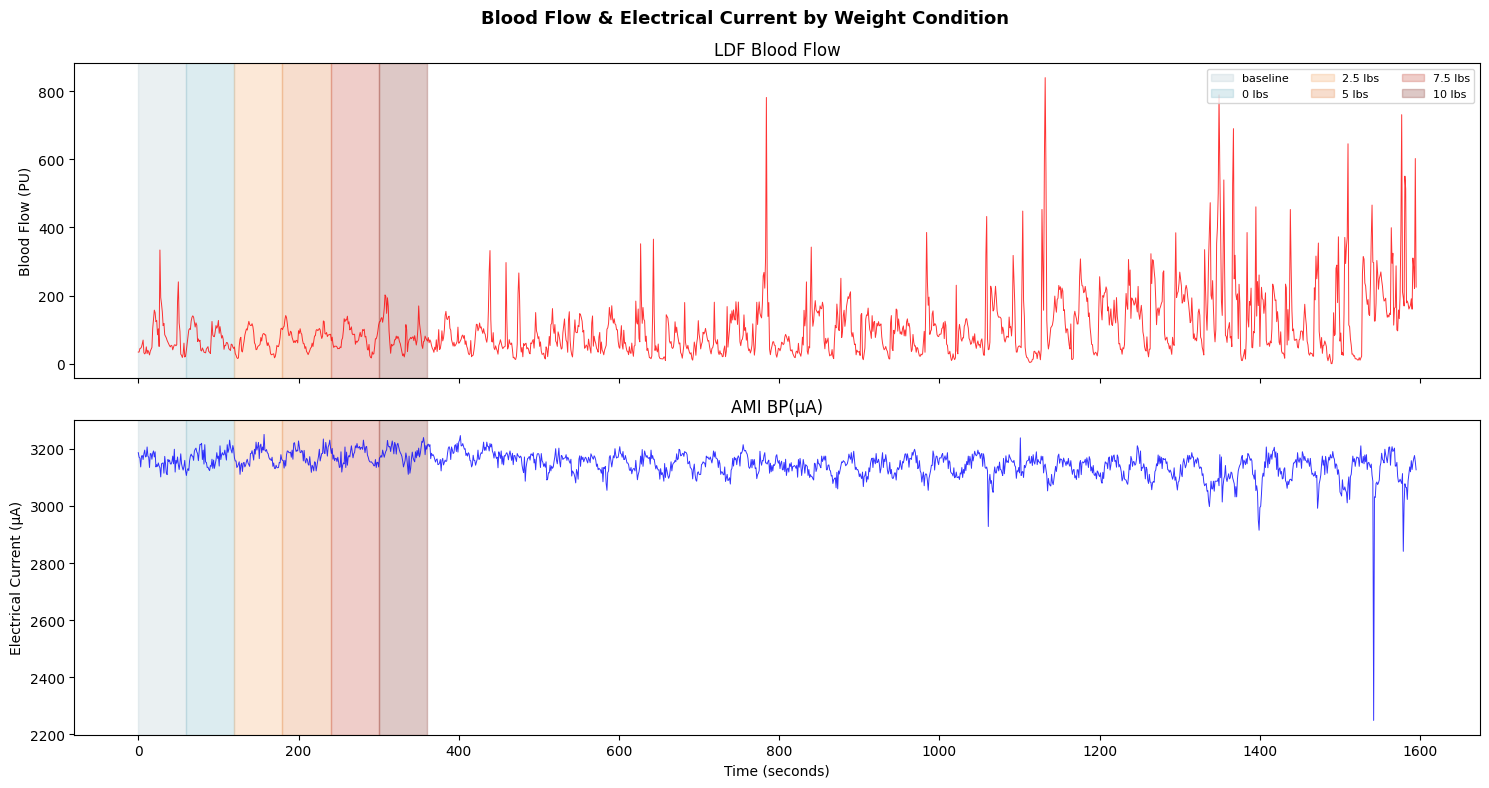

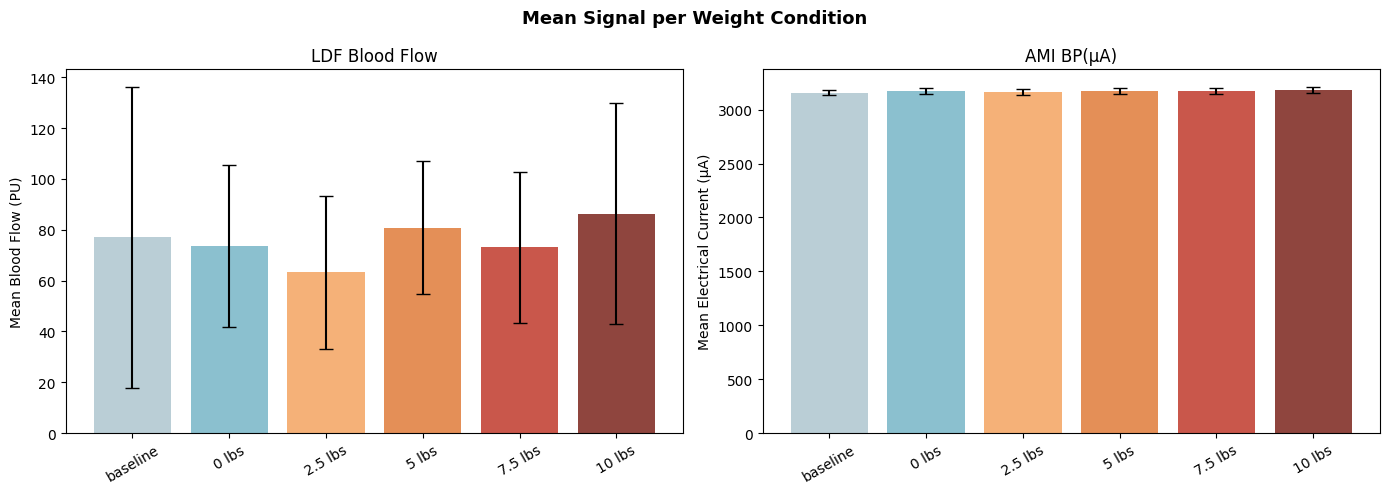

/var/folders/vv/qptpbkbs5cs9r65x9m88r15c0000gn/T/ipykernel_21635/2242807356.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([ldf_segments[c] for c in conditions],
/var/folders/vv/qptpbkbs5cs9r65x9m88r15c0000gn/T/ipykernel_21635/2242807356.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([ami_segments[c] for c in conditions],


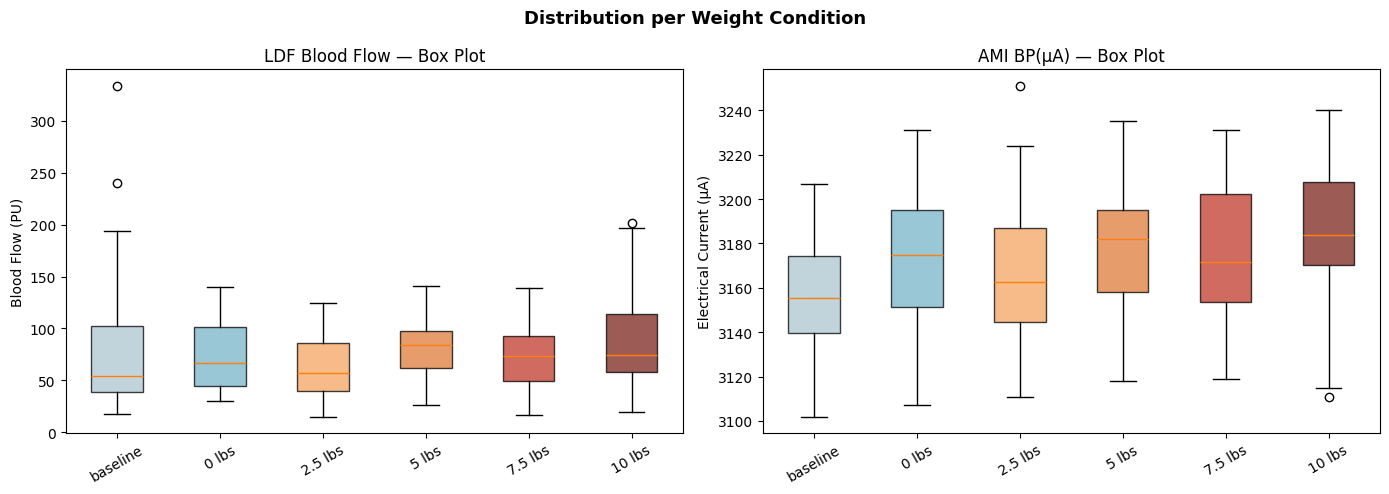


ONE-WAY ANOVA — does weight condition affect the signal?
LDF:  F=2.459,  p=3.2932e-02  ** SIGNIFICANT **
AMI:  F=7.181,  p=2.0344e-06  ** SIGNIFICANT **

Pairwise t-test vs baseline:
Condition    LDF p-value   AMI p-value
0 lbs         6.9124e-01    1.8190e-03*
2.5 lbs       1.1057e-01    3.5579e-02*
5 lbs         6.5444e-01    4.7841e-05*
7.5 lbs       6.4842e-01    1.1500e-04*
10 lbs        3.3695e-01    3.7713e-08*
(* = significantly different from baseline, p < 0.05)


In [ ]:

# WEIGHT-LOAD ANALYSIS

WEIGHT_WINDOWS = {
    'baseline': (0,   60),  
    '0 lbs':    (60,  120), 
    '2.5 lbs':  (120, 180), 
    '5 lbs':    (180, 240), 
    '7.5 lbs':  (240, 300),
    '10 lbs':   (300, 360),
}

# Colors for each condition (baseline → lightest, heaviest → darkest)
CONDITION_COLORS = {
    'baseline': '#aec6cf',
    '0 lbs':    '#77b5c7',
    '2.5 lbs':  '#f4a460',
    '5 lbs':    '#e07b39',
    '7.5 lbs':  '#c0392b',
    '10 lbs':   '#7b241c',
}

# ---- Segment both signals by condition ----
from scipy.stats import f_oneway, ttest_ind

conditions   = list(WEIGHT_WINDOWS.keys())
ldf_segments = {}
ami_segments = {}

for cond, (t0, t1) in WEIGHT_WINDOWS.items():
    mask = (time_s >= t0) & (time_s < t1)
    ldf_segments[cond] = ldf_aligned[mask]
    ami_segments[cond] = ami_bp[mask]        # using BP(µA) channel
    n_pts = mask.sum()
    print(f"{cond:10s}  t={t0}-{t1}s  "
          f"LDF mean={ldf_segments[cond].mean():.1f}  "
          f"AMI mean={ami_segments[cond].mean():.1f}  "
          f"({n_pts} samples)")

# ---- Plot 1: Time series with shaded weight regions ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle("Blood Flow & Electrical Current by Weight Condition", fontsize=13, fontweight='bold')

ax1.plot(time_s, ldf_aligned, color='red', linewidth=0.7, alpha=0.8)
ax2.plot(time_s, ami_bp,      color='blue', linewidth=0.7, alpha=0.8)

for cond, (t0, t1) in WEIGHT_WINDOWS.items():
    color = CONDITION_COLORS.get(cond, 'gray')
    ax1.axvspan(t0, t1, alpha=0.25, color=color, label=cond)
    ax2.axvspan(t0, t1, alpha=0.25, color=color)

ax1.set_ylabel("Blood Flow (PU)")
ax1.set_title("LDF Blood Flow")
ax1.legend(loc='upper right', fontsize=8, ncol=3)
ax2.set_ylabel("Electrical Current (µA)")
ax2.set_xlabel("Time (seconds)")
ax2.set_title("AMI BP(µA)")

plt.tight_layout()
plt.show()

# ---- Plot 2: Mean ± std bar chart per condition ----
ldf_means = [ldf_segments[c].mean() for c in conditions]
ldf_stds  = [ldf_segments[c].std()  for c in conditions]
ami_means = [ami_segments[c].mean() for c in conditions]
ami_stds  = [ami_segments[c].std()  for c in conditions]
colors    = [CONDITION_COLORS.get(c, 'gray') for c in conditions]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mean Signal per Weight Condition", fontsize=13, fontweight='bold')

ax1.bar(conditions, ldf_means, yerr=ldf_stds, color=colors, capsize=5, alpha=0.85)
ax1.set_ylabel("Mean Blood Flow (PU)")
ax1.set_title("LDF Blood Flow")
ax1.tick_params(axis='x', rotation=30)

ax2.bar(conditions, ami_means, yerr=ami_stds, color=colors, capsize=5, alpha=0.85)
ax2.set_ylabel("Mean Electrical Current (µA)")
ax2.set_title("AMI BP(µA)")
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ---- Plot 3: Box plots ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution per Weight Condition", fontsize=13, fontweight='bold')

bp1 = ax1.boxplot([ldf_segments[c] for c in conditions],
                  labels=conditions, patch_artist=True)
for patch, c in zip(bp1['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax1.set_ylabel("Blood Flow (PU)")
ax1.set_title("LDF Blood Flow — Box Plot")
ax1.tick_params(axis='x', rotation=30)

bp2 = ax2.boxplot([ami_segments[c] for c in conditions],
                  labels=conditions, patch_artist=True)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax2.set_ylabel("Electrical Current (µA)")
ax2.set_title("AMI BP(µA) — Box Plot")
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ---- Statistical tests ----
print("\n" + "=" * 55)
print("ONE-WAY ANOVA — does weight condition affect the signal?")
print("=" * 55)

F_ldf, p_ldf = f_oneway(*[ldf_segments[c] for c in conditions])
F_ami, p_ami = f_oneway(*[ami_segments[c] for c in conditions])
print(f"LDF:  F={F_ldf:.3f},  p={p_ldf:.4e}  "
      f"{'** SIGNIFICANT **' if p_ldf < 0.05 else '(not significant)'}")
print(f"AMI:  F={F_ami:.3f},  p={p_ami:.4e}  "
      f"{'** SIGNIFICANT **' if p_ami < 0.05 else '(not significant)'}")

# Pairwise t-tests vs baseline
print("\nPairwise t-test vs baseline:")
baseline_ldf = ldf_segments['baseline']
baseline_ami = ami_segments['baseline']
print(f"{'Condition':10s}  {'LDF p-value':>12s}  {'AMI p-value':>12s}")
for cond in conditions[1:]:
    _, p_l = ttest_ind(baseline_ldf, ldf_segments[cond])
    _, p_a = ttest_ind(baseline_ami, ami_segments[cond])
    sig_l = '*' if p_l < 0.05 else ''
    sig_a = '*' if p_a < 0.05 else ''
    print(f"{cond:10s}  {p_l:12.4e}{sig_l}  {p_a:12.4e}{sig_a}")
print("(* = significantly different from baseline, p < 0.05)")
